# Notebook 08: Uncertainty and the thresholds we choose

**Goal (two or three sessions):** put error bars on the pooled results and, just as important, measure how much the results depend on the pre-processing gates and post-processing thresholds in the pipeline. The idea to take away: *a result is the measurement plus the choices that produced it; benchmark both.*

Four sources of uncertainty, from smallest to largest in practice:

1. **Formal** error on each measurement (from the misfit surface; `phi_error`, `dt_error`).
2. **Sampling** error on the pooled mean (bootstrap).
3. **Threshold** sensitivity: what happens to N, mean phi and mean dt when the grade-3 cuts and pre-gates move.
4. **Processing** sensitivity: what happens to a single measurement when the pick, windows or filter move.

In [1]:
# --- setup: make the repo importable and keep figures inline ---
import sys, warnings
from pathlib import Path
REPO = Path.cwd().parent if (Path.cwd() / "../rainier_sws").exists() else Path.cwd()
sys.path.insert(0, str(REPO))
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
from rainier_sws import paths, data, measure, quality, stats
print("repo:", REPO)

repo: /home/claude/rainier-sws-tutorials


In [2]:
STATIONS = ["STAR", "RCM", "MILD"]
res = {s: pd.read_csv(paths.station_results_csv(s)) for s in STATIONS}

## 1. Formal errors: are they believable?

The formal errors say how wide the misfit valley is. In notebook 05 you saw that at low SNR the *actual* error is much larger than the valley width suggests. Compare the distribution of reported errors with SNR and with Q_w.

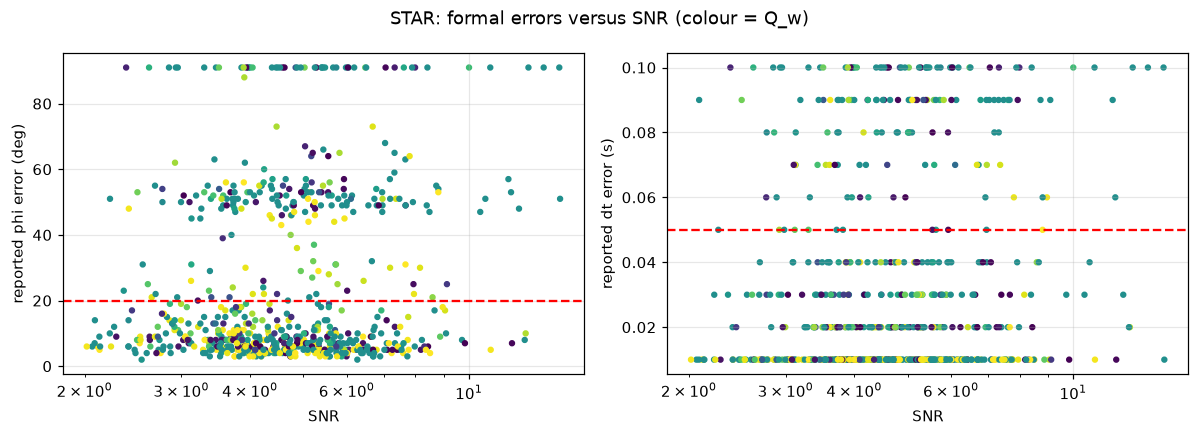

In [3]:
ok = quality.successful(res["STAR"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(ok.snr_horizontal, ok.phi_error, s=10, c=ok.quality, cmap="viridis"); axes[0].set_xscale("log")
axes[0].set_xlabel("SNR"); axes[0].set_ylabel("reported phi error (deg)"); axes[0].axhline(20, color="r", ls="--")
axes[1].scatter(ok.snr_horizontal, ok.dt_error, s=10, c=ok.quality, cmap="viridis"); axes[1].set_xscale("log")
axes[1].set_xlabel("SNR"); axes[1].set_ylabel("reported dt error (s)"); axes[1].axhline(0.05, color="r", ls="--")
fig.suptitle("STAR: formal errors versus SNR (colour = Q_w)"); plt.tight_layout()

Formal errors do shrink with SNR, as they should. But note the many low-SNR measurements with *small* reported errors: a narrow valley in a noisy surface. This is why the pipeline requires SNR and Q_w as well as small errors. A proper calibration (synthetic events pushed through the full SWSPy pipeline, as notebook 05 did with the toy version) is a good stretch project; the exercise at the end sets it up.

## 2. Sampling error: bootstrap intervals on the pooled result

Resample the grade-3 events with replacement, recompute the mean, repeat 1,000 times. The spread of those means is the uncertainty of the pooled estimate due to having only N events. For phi we use axial statistics (`rainier_sws/stats.py`).

In [4]:
rows = []
for s in STATIONS:
    g3 = quality.grade3(res[s])
    m, lo, hi, _ = stats.bootstrap_axial_mean(g3.phi, n_boot=1000)
    dt_m, dt_lo, dt_hi, _ = stats.bootstrap(g3.dt.values, np.mean, n_boot=1000)
    pa_m, pa_lo, pa_hi, _ = stats.bootstrap(g3.pct_anisotropy.dropna().values, np.mean, n_boot=1000)
    z, p = stats.rayleigh_test(g3.phi)
    rows.append({"station": s, "N": len(g3), "mean_phi": m, "phi_-": lo, "phi_+": hi, "circ_std": stats.axial_std(g3.phi),
                 "rayleigh_p": p, "mean_dt": dt_m, "dt_68%": f"[{dt_lo:.3f}, {dt_hi:.3f}]",
                 "mean_pct_aniso": pa_m, "pct_68%": f"[{pa_lo:.2f}, {pa_hi:.2f}]"})
summary = pd.DataFrame(rows).set_index("station").round(3)
summary

,N,mean_phi,phi_-,phi_+,circ_std,rayleigh_p,mean_dt,dt_68%,mean_pct_aniso,pct_68%
station,,,,,,,,,,
STAR,121,90.242,-2.543,1.751,37.945,0.000,0.040,"[0.038, 0.043]",2.266,"[2.13, 2.38]"
RCM,45,149.797,-2.361,2.158,15.728,0.000,0.054,"[0.052, 0.056]",3.373,"[3.21, 3.55]"
MILD,25,109.306,-4.114,5.065,36.703,0.007,0.046,"[0.043, 0.050]",2.273,"[2.13, 2.41]"


How to read it: STAR's mean fast direction is about 90 degrees with a 68 percent interval of a few degrees either side and a Rayleigh p-value far below 0.05 (a real preferred axis). RCM and MILD have wider intervals because N is smaller. The circular standard deviation (tens of degrees) is the spread of *individual* measurements and is much larger than the interval on the *mean*; both matter and they answer different questions.

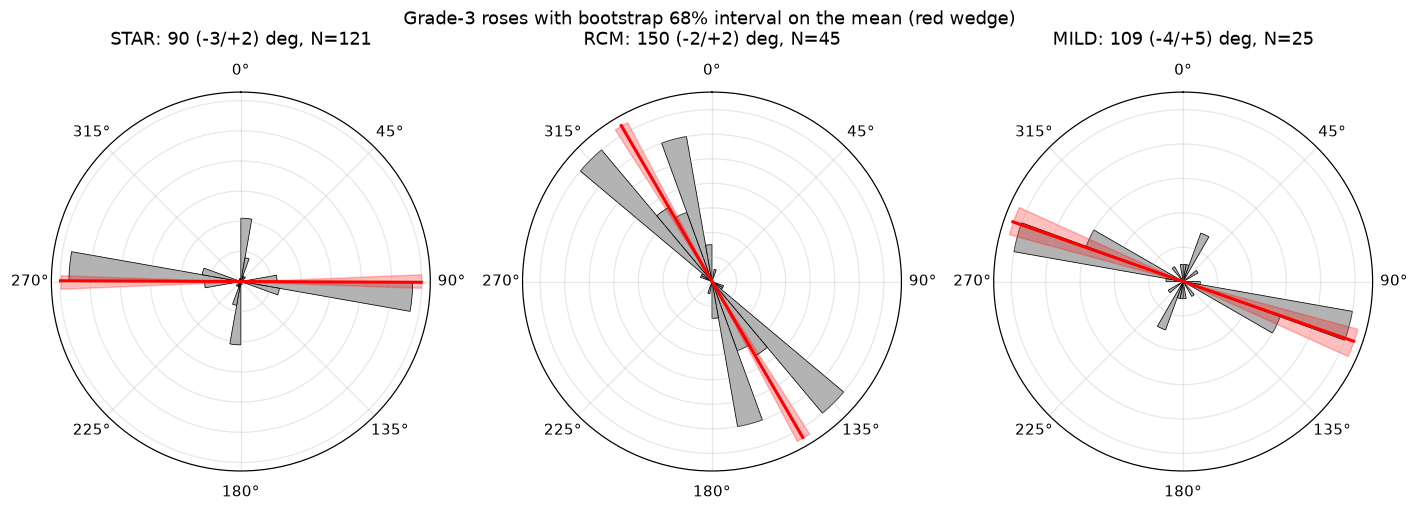

In [5]:
fig = plt.figure(figsize=(13, 4.5))
for i, s in enumerate(STATIONS):
    g3 = quality.grade3(res[s]); r = summary.loc[s]
    ax = fig.add_subplot(1, 3, i + 1, projection="polar"); ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    phi = measure.phi_0_180(g3.phi); bins = np.arange(0, 181, 10); c, _ = np.histogram(phi, bins)
    th = np.deg2rad(np.concatenate([bins[:-1], bins[:-1] + 180]))
    ax.bar(th, np.concatenate([c, c]), width=np.deg2rad(10), color="0.7", edgecolor="k", lw=0.5, align="edge")
    rmax = ax.get_ylim()[1]
    for base in (0, 180):
        ax.plot([np.deg2rad(r.mean_phi + base)] * 2, [0, rmax], "r-", lw=2)
        wedge = np.deg2rad(np.linspace(r.mean_phi + r["phi_-"] + base, r.mean_phi + r["phi_+"] + base, 20))
        ax.fill_between(wedge, 0, rmax, color="r", alpha=0.25)
    ax.set_yticklabels([]); ax.set_title(f"{s}: {r.mean_phi:.0f} ({r['phi_-']:+.0f}/{r['phi_+']:+.0f}) deg, N={int(r.N)}", pad=12)
fig.suptitle("Grade-3 roses with bootstrap 68% interval on the mean (red wedge)"); plt.tight_layout()

## 3. Post-processing thresholds: sweep the grade-3 cuts

Each grade-3 cut is a parameter in `quality.Grade3`. Sweep one at a time and track N, mean phi and mean dt. A result that is stable across reasonable values is robust; one that jumps is telling you the threshold is doing the work.

In [6]:
def summarize(r, g):
    g3 = quality.grade3(r, g)
    if len(g3) < 5: return {"N": len(g3), "mean_phi": np.nan, "R": np.nan, "mean_dt": np.nan}
    m, R = stats.axial_mean(g3.phi)
    return {"N": len(g3), "mean_phi": m, "R": R, "mean_dt": g3.dt.mean()}

sweeps = {
    "qw_min": [0.3, 0.4, 0.5, 0.6, 0.75, 0.9],
    "snr_min": [1.5, 2.0, 2.5, 3.0, 4.0, 6.0],
    "phi_error_max": [5, 10, 15, 20, 30, 45],
    "dt_error_max": [0.01, 0.02, 0.03, 0.05, 0.08, 0.12],
}
rows = []
for s in STATIONS:
    for param, values in sweeps.items():
        for v in values:
            g = quality.Grade3(**{param: v})
            rows.append({"station": s, "param": param, "value": v, **summarize(res[s], g)})
sweep = pd.DataFrame(rows)
sweep[(sweep.station == "STAR") & (sweep.param == "qw_min")]

,station,param,value,N,mean_phi,R,mean_dt
0,STAR,qw_min,0.30,132,91.239438,0.447406,0.042424
1,STAR,qw_min,0.40,127,90.471206,0.428496,0.041417
2,STAR,qw_min,0.50,121,90.242307,0.415947,0.040496
3,STAR,qw_min,0.60,118,89.828978,0.419963,0.040508
4,STAR,qw_min,0.75,110,91.365468,0.463891,0.038545
5,STAR,qw_min,0.90,104,91.155459,0.462629,0.037115


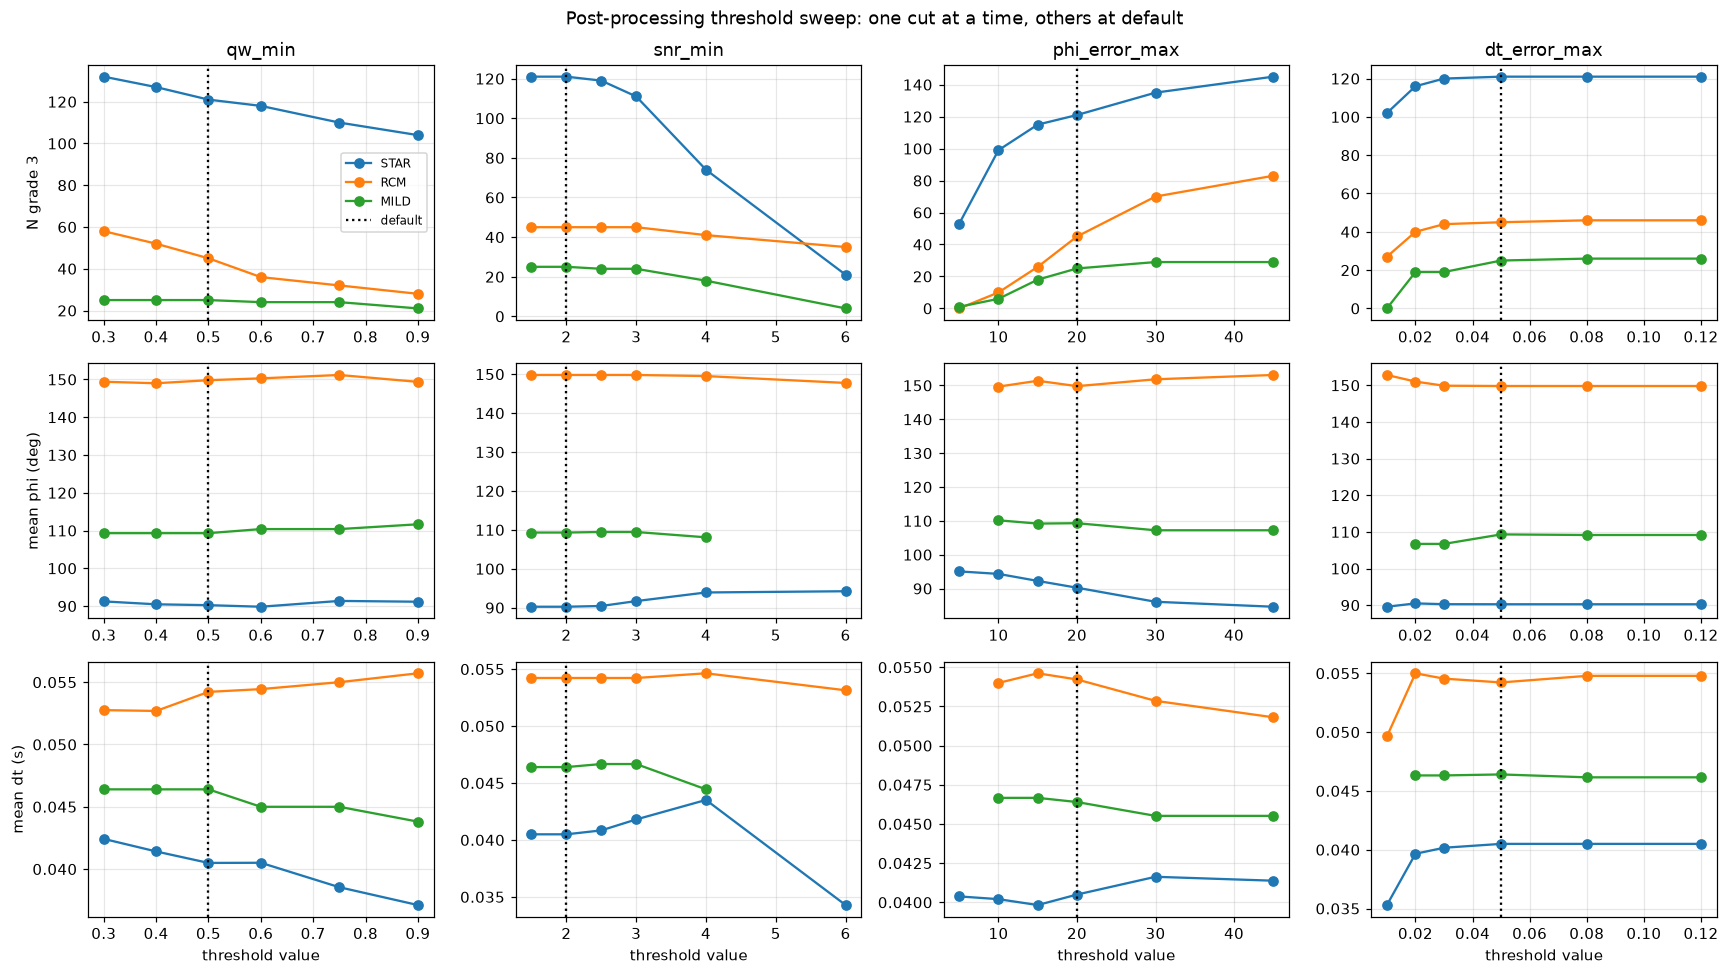

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for j, (param, values) in enumerate(sweeps.items()):
    for i, (metric, lab) in enumerate([("N", "N grade 3"), ("mean_phi", "mean phi (deg)"), ("mean_dt", "mean dt (s)")]):
        ax = axes[i, j]
        for s in STATIONS:
            d = sweep[(sweep.station == s) & (sweep.param == param)]
            ax.plot(d.value, d[metric], "o-", label=s)
        default = getattr(quality.DEFAULT_GRADE3, param)
        ax.axvline(default, color="k", ls=":", label="default" if (i == 0 and j == 0) else None)
        if i == 0: ax.set_title(param)
        if i == 2: ax.set_xlabel("threshold value")
        if j == 0: ax.set_ylabel(lab)
axes[0, 0].legend(fontsize=8); fig.suptitle("Post-processing threshold sweep: one cut at a time, others at default"); plt.tight_layout()

What to look for: N changes a lot (the cuts are doing their job), but does **mean phi** move by more than its bootstrap interval? For STAR it should barely move; that is a robust result. If a station's mean phi swings with Q_w or phi_error_max, the pooled direction is being decided by the filter, and the honest statement is "undetermined with this sample".

## 4. Pre-processing gates: the incidence cutoff

The pre-gates decide which events are *attempted*. The incidence gate removed almost everything at five stations. We cannot re-measure rejected events here (that needs the full re-run), but we can ask two cheaper questions with the stored angles: how many events each cutoff would admit, and for the events that were measured, does the mean phi depend on how steeply they arrived?

In [8]:
ALL = ["STAR", "RCM", "MILD", "LON", "PANH", "OBSR", "PARA", "RER", "COPP"]
allres = {s: pd.read_csv(paths.station_results_csv(s)) for s in ALL}
cutoffs = [30, 35, 40, 45, 50, 55, 60, 70]
admit = pd.DataFrame({s: [int((r.incidence_angle <= c).sum()) for c in cutoffs] for s, r in allres.items()}, index=cutoffs)
admit.index.name = "incidence cutoff (deg)"
admit

,STAR,RCM,MILD,LON,PANH,OBSR,PARA,RER,COPP
incidence cutoff (deg),,,,,,,,,
30,549,17,1,0,0,0,0,0,0
35,726,93,2,0,0,0,0,0,0
40,825,225,23,0,0,0,0,0,0
45,848,339,134,0,0,2,1,0,0
50,862,424,305,0,0,7,1,0,0
55,872,461,476,0,1,25,2,1,3
60,880,478,581,0,8,52,9,31,13
70,898,487,656,549,268,114,465,322,258


Text(0.5, 1.0, 'How many events each station would attempt versus the incidence cutoff')

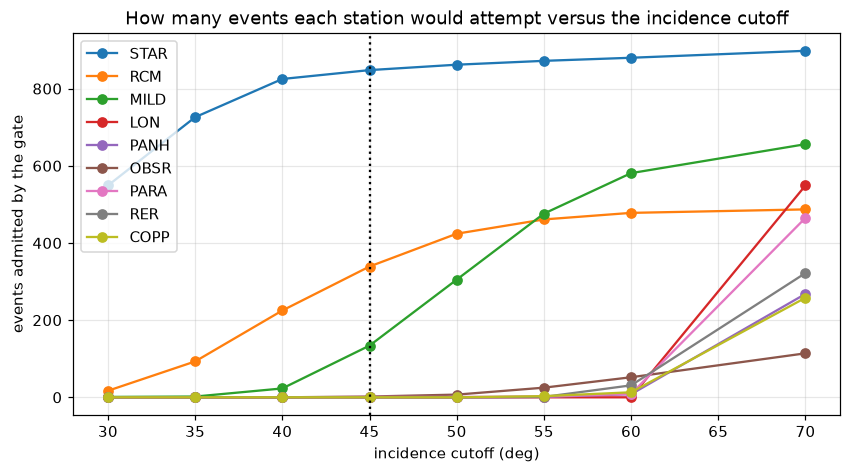

In [9]:
ax = admit.plot(figsize=(9, 4.5), marker="o"); ax.axvline(45, color="k", ls=":")
ax.set_ylabel("events admitted by the gate"); ax.set_title("How many events each station would attempt versus the incidence cutoff")

For PANH, PARA, RER and COPP the curve stays at zero until far past 45 degrees: the geometry really is outside the shear-wave window under this velocity model. OBSR and MILD are borderline. Relaxing the cutoff is *not* a free lunch: beyond about 45 degrees the free-surface reflection distorts S-wave particle motion and the measurement loses its meaning (Crampin & Peacock, 2008). The right benchmark is therefore not "how many events can we admit" but "at what angle do the measurements become unreliable", which is a synthetic or a near-station versus far-station comparison. Write that down as a project idea.

In [10]:
# Among measured STAR events, does phi depend on incidence angle? (bins of ray-traced angle)
g3 = quality.grade3(allres["STAR"]).copy()
g3["inc_bin"] = pd.cut(g3.incidence_angle, [0, 20, 30, 40, 45])
tab = g3.groupby("inc_bin", observed=True).agg(N=("phi", "size"), mean_phi=("phi", lambda p: stats.axial_mean(p)[0]),
                                               R=("phi", lambda p: stats.axial_mean(p)[1]), mean_dt=("dt", "mean")).round(2)
tab

,N,mean_phi,R,mean_dt
inc_bin,,,,
"(0, 20]",14,98.15,0.71,0.06
"(20, 30]",80,92.00,0.41,0.04
"(30, 40]",26,76.88,0.32,0.03
"(40, 45]",1,54.06,1.00,0.06


## 5. Null screening

Flag grade-3 events whose fast axis is within 20 degrees of the back azimuth or of its perpendicular. Report the pooled mean with and without them. If the answer changes, the pooled direction may be partly an artifact of initial polarization.

In [11]:
rows = []
for s in STATIONS:
    g3 = quality.grade3(res[s]).copy()
    d = stats.axial_diff(g3.phi, g3.back_azimuth)
    g3["near_null"] = (d <= 20) | (d >= 70)
    keep = g3[~g3.near_null]
    m_all, R_all = stats.axial_mean(g3.phi); m_keep, R_keep = stats.axial_mean(keep.phi) if len(keep) >= 5 else (np.nan, np.nan)
    rows.append({"station": s, "N": len(g3), "N_near_null": int(g3.near_null.sum()), "frac_near_null": round(g3.near_null.mean(), 2),
                 "mean_phi_all": round(m_all, 1), "mean_phi_without": round(m_keep, 1), "R_all": round(R_all, 2), "R_without": round(R_keep, 2)})
pd.DataFrame(rows).set_index("station")

,N,N_near_null,frac_near_null,mean_phi_all,mean_phi_without,R_all,R_without
station,,,,,,,
STAR,121,109,0.90,90.2,46.0,0.42,0.48
RCM,45,19,0.42,149.8,159.6,0.86,0.92
MILD,25,23,0.92,109.3,NaN,0.44,NaN


At STAR the large majority of grade-3 measurements are near-null by this definition, because nearly all rays arrive from the east and the fast axis is east-west. That does not make them wrong; it means the dataset cannot by itself distinguish a real east-west fast axis from a polarization effect. This is probably the single most important caveat on the preliminary results, and it argues for exactly what the project plans next: more stations, better geometry, and the nodal array.

## 6. Processing sensitivity on one event

Finally, the knobs inside a single measurement. Re-measure the figure-3 event with the S pick shifted, with more or fewer windows, and with the second-best filter band. Each run takes about 15 s.

In [12]:
cat = data.load_station_catalog("STAR")
row = cat[cat.evid == 61504668].iloc[0]
ev = data.get_event_stream("STAR", row, allow_download=False)
lat, lon, _ = data.station_coords("STAR")
inc = float(res["STAR"].set_index("evid").loc[61504668, "incidence_angle"])

def run(label, row=row, params=measure.SwsParams()):
    m = measure.measure_event(row, ev, "STAR", lat, lon, incidence_angle=inc, params=params)
    return {"case": label, "stage": m.stage, "phi": m.phi, "dt": m.dt, "phi_err": m.phi_error, "dt_err": m.dt_error, "Q_w": m.quality}

cases = [run("baseline")]
for shift in (-0.03, +0.03):
    r2 = row.copy(); r2["s_time"] = row.s_time + pd.Timedelta(seconds=shift)
    cases.append(run(f"S pick {shift:+.2f} s", row=r2))
cases.append(run("n_win = 3", params=measure.SwsParams(n_win=3)))
cases.append(run("n_win = 11", params=measure.SwsParams(n_win=11)))
cases.append(run("max_t_shift = 0.1 s", params=measure.SwsParams(max_t_shift_s=0.1)))
cases.append(run("s_pick_uncertainty = 0.06", params=measure.SwsParams(s_pick_uncertainty=0.06)))
pd.DataFrame(cases).set_index("case").round(3)

,stage,phi,dt,phi_err,dt_err,Q_w
case,,,,,,
baseline,ok,-88.783,0.02,4.0,0.01,1.000
S pick -0.03 s,ok,11.217,0.02,4.0,0.01,0.000
S pick +0.03 s,ok,-88.783,0.02,4.0,0.01,0.969
n_win = 3,fail_no_result,NaN,NaN,NaN,NaN,NaN
n_win = 11,ok,-88.783,0.02,4.0,0.01,1.000
max_t_shift = 0.1 s,ok,-88.783,0.02,5.0,0.01,1.000
s_pick_uncertainty = 0.06,ok,-88.783,0.02,4.0,0.01,1.000


Read this table carefully; it is more interesting than it looks.

- Most knobs leave the answer untouched: phi -88.8, dt 0.02, Q_w about 1. That is what a robust measurement looks like.
- `n_win = 3` fails outright: the clustering step needs at least `cluster_min_samples` (15) window results, and 3 windows cannot provide them. A parameter can be *incompatible* with another, not just worse.
- **Shifting the S pick 0.03 s earlier flips phi by 100 degrees and drops Q_w to 0.** One pick error of three samples, well within an analyst's typical uncertainty, produces a completely different fast direction, and the only thing standing between that number and the final rose is the Q_w threshold. This is the whole argument for benchmarking thresholds alongside measurements: the quality score caught it here; the sweep in section 3 tells you how often it would not.

Repeat this for a *marginal* event (Q_w near 0.5, SNR near 2) and watch more of the rows fall apart.

## 7. Turning this into a benchmark

Everything above is a one-off. The deliverable for the project is a function that takes a station's results and a set of thresholds and returns the summary table of section 2 plus the sensitivity of section 3, so that *every* station and every future re-run is judged the same way. A sketch:

In [13]:
def benchmark(results: pd.DataFrame, grade: quality.Grade3 = quality.DEFAULT_GRADE3, n_boot=500) -> dict:
    """Pooled estimate with uncertainty, plus its sensitivity to each grade-3 threshold."""
    g3 = quality.grade3(results, grade)
    m, lo, hi, _ = stats.bootstrap_axial_mean(g3.phi, n_boot=n_boot)
    out = {"N": len(g3), "mean_phi": m, "phi_ci": (lo, hi), "mean_dt": g3.dt.mean(),
           "dt_ci": stats.bootstrap(g3.dt.values, np.mean, n_boot=n_boot)[1:3]}
    for param, values in sweeps.items():
        phis = [summarize(results, quality.Grade3(**{param: v}))["mean_phi"] for v in values]
        out[f"phi_range_vs_{param}"] = float(np.nanmax(stats.axial_diff(phis, m)))   # worst-case swing of mean phi
    return {k: (tuple(round(x, 3) for x in v) if isinstance(v, tuple) else (round(v, 3) if isinstance(v, float) else v)) for k, v in out.items()}

pd.DataFrame({s: benchmark(res[s]) for s in STATIONS}).T

,N,mean_phi,phi_ci,mean_dt,dt_ci,phi_range_vs_qw_min,phi_range_vs_snr_min,phi_range_vs_phi_error_max,phi_range_vs_dt_error_max
STAR,121,90.242,"(-2.672, 1.733)",0.04,"(0.038, 0.043)",1.123,3.98,5.62,0.675
RCM,45,149.797,"(-2.235, 2.216)",0.054,"(0.052, 0.056)",1.385,2.044,3.303,3.013
MILD,25,109.306,"(-4.118, 5.548)",0.046,"(0.043, 0.05)",2.347,1.227,2.091,2.593


`phi_range_vs_<param>` is the largest swing of the mean fast direction as that threshold moves across its sweep. If it is smaller than the bootstrap interval, the result is threshold-robust. That single comparison is the standard you will apply as you scale to more stations.

## 8. Exercises and project ideas

1. Run `benchmark` for LON and for the VT background at STAR (`results/sws_vt_star_results.csv`). Is the background fast direction the same as the swarm's?
2. Repeat section 6 for a marginal event. Which knob breaks it first?
3. Change the near-null definition to 10 and 30 degrees. How sensitive is the fraction?
4. **Calibration project:** generate synthetic split events by taking a clean STAR S wave, undoing its splitting with `swspy.splitting.split_windowcheck.remove_splitting`, re-splitting with known (phi, dt), adding real pre-event noise at chosen SNR, and pushing the result through `measure_event`. Compare recovered errors with the reported ones. This is the real version of notebook 05, section 5.
5. **Incidence-gate project:** using the synthetic events above with the LQT rotation at several nominal incidence angles, find the angle at which recovery degrades. Compare with the 45-degree gate.

When you can run `benchmark` on every station from one script and explain each number in it, you are done with this tutorial series and ready for the real analysis.

That script is the week-8 deliverable. What comes after it, in priority order, is the *Winter quarter* section of the README: the timing correction from notebook 05b applied to the pipeline, the 2009 swarm at STAR, all of 2025 at STAR, and a first look at the nodes.